# Meteora DLMM Bin Atlas: connecting, fetching, normalizing, visualizing

This notebook explores Meteora DLMM bin-level liquidity using a read-only Solana RPC connection. It does not run a Solana node, does not use a wallet, and does not submit transactions.

## Environment

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path
from urllib.parse import urlparse
from dotenv import load_dotenv

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
PLOTS_DIR = PROJECT_ROOT / "plots"

load_dotenv(PROJECT_ROOT / ".env")


def latest_matching(directory: Path, pattern: str) -> Path:
    matches = sorted(directory.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No files matching {pattern} in {directory}")
    return matches[-1]


print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/echow/Desktop/meteora_bin_atlas


## RPC model

We connect through an RPC provider using `SOLANA_RPC_URL`. This is read-only. We never print the full URL (it may contain API keys).

In [2]:
rpc_url = os.getenv("SOLANA_RPC_URL", "")
rpc_host = urlparse(rpc_url).hostname or "(not set)"
cluster = os.getenv("SOLANA_CLUSTER", "mainnet-beta")

print(f"RPC host: {rpc_host}")
print(f"Cluster: {cluster}")

RPC host: api.mainnet-beta.solana.com
Cluster: mainnet-beta


## Fetch pool candidates

Run the TypeScript discovery script, then load the processed CSV.

In [3]:
!cd {PROJECT_ROOT} && npm run discover:pools


> meteora-bin-atlas@0.1.0 discover:pools
> tsx src/scripts/step1_discover_pools.ts

Discovery method: meteora_api
Candidate pools: 10
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/pools_2026-06-07T05-36-00-914Z.json
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/pool_candidates.csv
Warnings:
- Legacy Meteora API https://dlmm-api.meteora.ag/pair/all returned HTTP 404; using https://dlmm.datapi.meteora.ag/pools instead.
Pool discovery complete.
⠙

In [4]:
pool_candidates_path = DATA_PROCESSED / "pool_candidates.csv"
pool_candidates = pd.read_csv(pool_candidates_path)
pool_candidates.head()

,pool_address,token_x_mint,token_y_mint,bin_step,active_bin_id,raw_name_or_symbol_if_available,source,fetched_at_utc
0,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,So11111111111111111111111111111111111111112,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,4,-6865,SOL-USDC,meteora_api,2026-06-07T05:36:00.915Z
1,9p3aRWnbu5vAmHXvsToMGfwmbkTJSwGr5G5xxSxmkB8N,CWZ6BsdnjkDVTGkmL6bGbJXXig6ceef12KvyGQW14cMt,Es9vMFrzaCERmJfrF4H2FYD4KCoNkY11McCe8BenwNYB,80,-490,ANTFUN-USDT,meteora_api,2026-06-07T05:36:00.915Z
2,ANCx141SujgVdbKz9NTEH8F38qWsnyyXsVju64aU3qLB,98sMhvDwXj1RQi5c5Mndm3vPe9cBqPrbLaufMXFNMh5g,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,20,-1415,HYPE-USDC,meteora_api,2026-06-07T05:36:00.915Z
3,7ubS3GccjhQY99AYNKXjNJqnXjaokEdfdV915xnCb96r,cbbtcf3aa214zXHbiAZQwf4122FBYbraNdFqgw4iMij,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,4,16068,cbBTC-USDC,meteora_api,2026-06-07T05:36:00.915Z
4,HcCbiQqc55uHtP2MJu7BYdVPi9s4j45R4zXcwRmJgCXX,So11111111111111111111111111111111111111112,EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v,5,-5492,SOL-USDC,meteora_api,2026-06-07T05:36:00.915Z


## Choose one pool

Use the first discovered candidate, or set `POOL_ADDRESS` manually.

In [5]:
POOL_ADDRESS = pool_candidates.iloc[0]["pool_address"]
# POOL_ADDRESS = "5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6"

selected = pool_candidates[pool_candidates["pool_address"] == POOL_ADDRESS].iloc[0]
print(f"Pool: {POOL_ADDRESS}")
print(f"Label: {selected.get('raw_name_or_symbol_if_available', '')}")
print(f"Bin step: {selected.get('bin_step', '')}")

Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Label: SOL-USDC
Bin step: 4


## Fetch pool snapshot

In [6]:
!cd {PROJECT_ROOT} && npm run fetch:pool -- --pool {POOL_ADDRESS}


> meteora-bin-atlas@0.1.0 fetch:pool
> tsx src/scripts/step2_fetch_pool_snapshot.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Active bin ID: -6865
Active bin price: 64.219334935431137057
Bin step: 4 bps
Token X mint: So11111111111111111111111111111111111111112
Token Y mint: EPjFWdd5AufqSSqeM2qN1xzybapC8G4wEGGkZwyTDt1v
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/pool_snapshot_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-36-02-931Z.json
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/pool_snapshot_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-36-02-931Z.json
Pool snapshot complete.
⠙

## Fetch bin arrays

In [7]:
!cd {PROJECT_ROOT} && npm run fetch:bins -- --pool {POOL_ADDRESS}


> meteora-bin-atlas@0.1.0 fetch:bins
> tsx src/scripts/step3_fetch_bin_arrays.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Pool: 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6
Method: getBinArrays
Bin arrays fetched: 195
Active bin ID: -6865
Raw output: /Users/echow/Desktop/meteora_bin_atlas/data/raw/bin_arrays_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-36-04-081Z.json
Bin arrays fetch complete.
⠙

## Normalize bin atlas

In [8]:
!cd {PROJECT_ROOT} && npm run normalize:bins -- --pool {POOL_ADDRESS}


> meteora-bin-atlas@0.1.0 normalize:bins
> tsx src/scripts/step4_normalize_bin_atlas.ts --pool 5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6

Input: /Users/echow/Desktop/meteora_bin_atlas/data/raw/bin_arrays_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-36-04-081Z.json
Method: getBinArrays
Bins normalized: 13650
Active bin rows: 1
Bins with non-zero liquidity: 4978
Active bin ID: -6865
Processed output: /Users/echow/Desktop/meteora_bin_atlas/data/processed/bin_atlas_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-36-04-082Z.csv
Bin atlas normalization complete.
⠙

## Load bin atlas

In [9]:
latest_bin_atlas_path = latest_matching(
    DATA_PROCESSED, f"bin_atlas_{POOL_ADDRESS}_*.csv"
)
df = pd.read_csv(latest_bin_atlas_path)
print(f"Loaded: {latest_bin_atlas_path.name}")
df.head()

Loaded: bin_atlas_5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6_2026-06-07T05-36-04-082Z.csv


,pool_address,fetched_at_utc,bin_array_index,bin_id,distance_from_active,price,price_per_token,liquidity,x_amount,y_amount,composition_y,is_active_bin,raw_bin_array_pubkey,raw_fields_json
0,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T05:36:04.082Z,-456,-31920,-25055,52717705093411,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52717705..."
1,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T05:36:04.082Z,-456,-31919,-25054,52738792175449,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52738792..."
2,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T05:36:04.082Z,-456,-31918,-25053,52759887692319,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52759887..."
3,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T05:36:04.082Z,-456,-31917,-25052,52780991647396,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52780991..."
4,5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6,2026-06-07T05:36:04.082Z,-456,-31916,-25051,52802104044055,NaN,0,0,0,NaN,False,HjCTcS967DCu7pzMf5SD2EoBs8q6HvjUa1qnRrXdcAD1,"{""amountX"":""0"",""amountY"":""0"",""price"":""52802104..."


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13650 entries, 0 to 13649
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pool_address          13650 non-null  str    
 1   fetched_at_utc        13650 non-null  str    
 2   bin_array_index       13650 non-null  int64  
 3   bin_id                13650 non-null  int64  
 4   distance_from_active  13650 non-null  int64  
 5   price                 13650 non-null  object 
 6   price_per_token       0 non-null      float64
 7   liquidity             13650 non-null  object 
 8   x_amount              13650 non-null  int64  
 9   y_amount              13650 non-null  int64  
 10  composition_y         4978 non-null   float64
 11  is_active_bin         13650 non-null  bool   
 12  raw_bin_array_pubkey  13650 non-null  str    
 13  raw_fields_json       13650 non-null  str    
dtypes: bool(1), float64(2), int64(5), object(2), str(4)
memory usage: 8.3+ MB


## Basic sanity checks

In [11]:
print("bin_id range:", df["bin_id"].min(), df["bin_id"].max())
print(
    "distance_from_active range:",
    df["distance_from_active"].min(),
    df["distance_from_active"].max(),
)
print("active bin rows:", df["is_active_bin"].astype(str).str.lower().eq("true").sum())

# Zoom window for plots (bins on each side of active)
ZOOM_BINS = 30

neighborhood_df = (
    df[df["distance_from_active"].between(-ZOOM_BINS, ZOOM_BINS)]
    .sort_values("bin_id")
    .copy()
)
neighborhood_df["liquidity"] = pd.to_numeric(neighborhood_df["liquidity"], errors="coerce").fillna(0)
neighborhood_df["x_amount"] = pd.to_numeric(neighborhood_df["x_amount"], errors="coerce").fillna(0)
neighborhood_df["y_amount"] = pd.to_numeric(neighborhood_df["y_amount"], errors="coerce").fillna(0)

print(f"\nNeighborhood rows (±{ZOOM_BINS} bins):", len(neighborhood_df))

bin_id range: -31920 30379
distance_from_active range: -25055 37244
active bin rows: 1

Neighborhood rows (±30 bins): 61


## DLMM side structure (why X and Y split around the active bin)

In a DLMM pool, liquidity is **not** symmetric around the active bin:

- **Bins below** the active bin (`distance_from_active < 0`) hold **token Y** (here: USDC). These are the bid side — liquidity waiting if price moves down.
- **Bins above** the active bin (`distance_from_active > 0`) hold **token X** (here: SOL). These are the ask side — liquidity waiting if price moves up.
- The **active bin** is the handoff: it typically holds a small mix of both as price sits on the boundary.

So it is normal to see **no Y on the ask side** and **no X on the bid side**. The data is not missing; that is how the lattice is laid out.

The **table below** lists every bin in the zoom window (±`ZOOM_BINS` around active) with side, what is stocked, and each bin's role. Rows are **color-coded by token**: blue = Y (USDC), purple = X (SOL), teal = both at the active bin. The **liquidity plot after that** uses the same colors.

In [12]:
POOL_LABEL = selected.get("raw_name_or_symbol_if_available", POOL_ADDRESS)
TOKEN_X = "SOL" if "SOL" in str(POOL_LABEL).split("-")[0] else "token X"
TOKEN_Y = str(POOL_LABEL).split("-")[-1] if "-" in str(POOL_LABEL) else "token Y"

# Shared token colors (table + plots)
TOKEN_COLORS = {
    "X": "#9945FF",  # SOL / token X
    "Y": "#2775CA",  # USDC / token Y
    "mix": "#14B8A6",  # active bin with both tokens
    "empty": "#D1D5DB",
}


def bar_color_for_bin(x_amount: float, y_amount: float) -> str:
    if x_amount > 0 and y_amount > 0:
        return TOKEN_COLORS["mix"]
    if y_amount > 0:
        return TOKEN_COLORS["Y"]
    if x_amount > 0:
        return TOKEN_COLORS["X"]
    return TOKEN_COLORS["empty"]


def side_label(distance: int) -> str:
    if distance < 0:
        return "Bid (below active)"
    if distance == 0:
        return "Active"
    return "Ask (above active)"


def stocked_label(x_amount: float, y_amount: float) -> str:
    if x_amount > 0 and y_amount > 0:
        return f"X + Y ({TOKEN_X} + {TOKEN_Y})"
    if y_amount > 0:
        return f"Y only ({TOKEN_Y})"
    if x_amount > 0:
        return f"X only ({TOKEN_X})"
    return "empty"


def role_label(distance: int) -> str:
    if distance < 0:
        return f"Pool pays {TOKEN_Y} if price drops to this shelf"
    if distance == 0:
        return "Current price / handoff between sides"
    return f"Pool pays {TOKEN_X} if price rises to this shelf"


bin_structure_df = neighborhood_df[
    ["distance_from_active", "bin_id", "x_amount", "y_amount", "is_active_bin"]
].copy()
bin_structure_df["side"] = bin_structure_df["distance_from_active"].map(side_label)
bin_structure_df["stocked"] = bin_structure_df.apply(
    lambda row: stocked_label(row["x_amount"], row["y_amount"]), axis=1
)
bin_structure_df["role"] = bin_structure_df["distance_from_active"].map(role_label)

display_cols = [
    "distance_from_active",
    "bin_id",
    "side",
    "stocked",
    "role",
    "x_amount",
    "y_amount",
]

print(f"Pool: {POOL_LABEL} ({POOL_ADDRESS})")
print(f"Active bin rows in zoom window: {bin_structure_df['is_active_bin'].sum()}\n")

summary = (
    bin_structure_df.groupby(["side", "stocked"], dropna=False)
    .size()
    .reset_index(name="bin_count")
    .sort_values(["side", "stocked"])
)
def style_token_row(row: pd.Series) -> list[str]:
    color = bar_color_for_bin(row["x_amount"], row["y_amount"])
    return [f"background-color: {color}22"] * len(row)


def style_summary_row(row: pd.Series) -> list[str]:
    stocked = row["stocked"]
    if "Y only" in stocked:
        color = TOKEN_COLORS["Y"]
    elif "X only" in stocked:
        color = TOKEN_COLORS["X"]
    elif "X + Y" in stocked:
        color = TOKEN_COLORS["mix"]
    else:
        color = TOKEN_COLORS["empty"]
    return [f"background-color: {color}22"] * len(row)


print("Pattern summary (should be Y-only on bid, X-only on ask, mix at active):")
display(
    summary.style.apply(style_summary_row, axis=1).set_caption(
        f"Color key: {TOKEN_Y} = blue, {TOKEN_X} = purple, mix = teal"
    )
)

print(f"\nFull bin ladder (±{ZOOM_BINS} around active):")
display(
    bin_structure_df[display_cols]
    .style.apply(style_token_row, axis=1)
    .set_caption(
        f"Rows colored by stocked token: {TOKEN_Y} (Y), {TOKEN_X} (X), or both at active"
    )
)

Pool: SOL-USDC (5rCf1DM8LjKTw4YqhnoLcngyZYeNnQqztScTogYHAS6)
Active bin rows in zoom window: 1

Pattern summary (should be Y-only on bid, X-only on ask, mix at active):


,side,stocked,bin_count
0,Active,X + Y (SOL + USDC),1
1,Ask (above active),X only (SOL),30
2,Bid (below active),Y only (USDC),30



Full bin ladder (±30 around active):


,distance_from_active,bin_id,side,stocked,role,x_amount,y_amount
8645,-30,-6895,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1342543940
8646,-29,-6894,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1351771000
8647,-28,-6893,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1386965058
8648,-27,-6892,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1393073920
8649,-26,-6891,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1401737121
8650,-25,-6890,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1412943626
8651,-24,-6889,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1421979454
8652,-23,-6888,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1431430184
8653,-22,-6887,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1441131157
8654,-21,-6886,Bid (below active),Y only (USDC),Pool pays USDC if price drops to this shelf,0,1456539133


## Visualize liquidity by bin

Zoomed to ±`ZOOM_BINS` around the active bin. Compare with the table above: bid shelves below, ask shelves above.

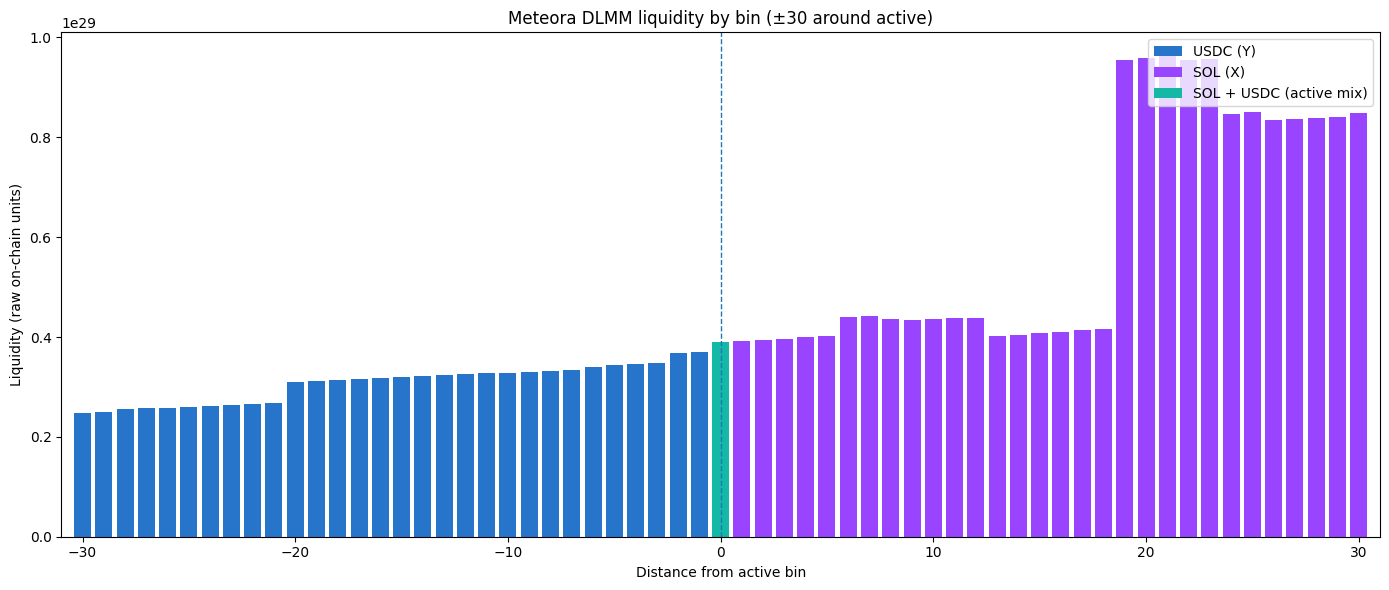

In [13]:
from matplotlib.patches import Patch

plot_df = neighborhood_df
bar_colors = plot_df.apply(
    lambda row: bar_color_for_bin(row["x_amount"], row["y_amount"]), axis=1
)

fig, ax = plt.subplots(figsize=(14, 6))
bar_width = 0.8
ax.bar(
    plot_df["distance_from_active"],
    plot_df["liquidity"],
    width=bar_width,
    color=bar_colors,
)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlim(-ZOOM_BINS - 1, ZOOM_BINS + 1)
ax.set_xlabel("Distance from active bin")
ax.set_ylabel("Liquidity (raw on-chain units)")
ax.set_title(f"Meteora DLMM liquidity by bin (±{ZOOM_BINS} around active)")
ax.legend(
    handles=[
        Patch(facecolor=TOKEN_COLORS["Y"], label=f"{TOKEN_Y} (Y)"),
        Patch(facecolor=TOKEN_COLORS["X"], label=f"{TOKEN_X} (X)"),
        Patch(facecolor=TOKEN_COLORS["mix"], label=f"{TOKEN_X} + {TOKEN_Y} (active mix)"),
    ],
    loc="upper right",
)
fig.tight_layout()
plt.show()

## Visualize token composition

Same zoom window, split into bid (Y) and ask (X) panels. Raw on-chain units — the **side split** is the point, not exact magnitude comparison.

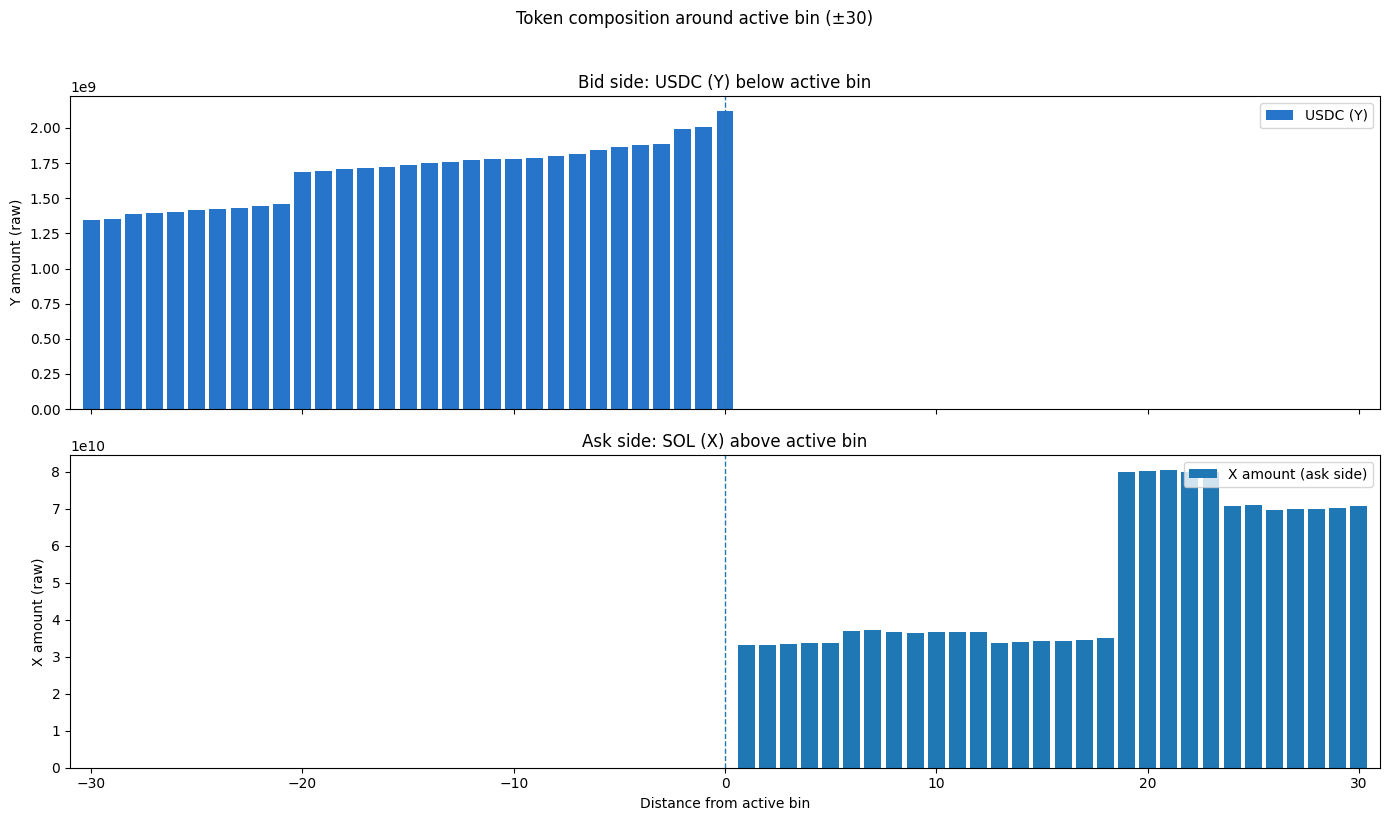

In [14]:
plot_df = neighborhood_df

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

bid_side = plot_df[plot_df["distance_from_active"] <= 0]
ask_side = plot_df[plot_df["distance_from_active"] >= 0]

axes[0].bar(
    bid_side["distance_from_active"],
    bid_side["y_amount"],
    width=0.8,
    color=TOKEN_COLORS["Y"],
    label=f"{TOKEN_Y} (Y)",
)
axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].set_ylabel("Y amount (raw)")
axes[0].set_title("Bid side: USDC (Y) below active bin")
axes[0].legend(loc="upper right")

axes[1].bar(
    ask_side["distance_from_active"],
    ask_side["x_amount"],
    width=0.8,
    label="X amount (ask side)",
)
axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].set_xlim(-ZOOM_BINS - 1, ZOOM_BINS + 1)
axes[1].set_xlabel("Distance from active bin")
axes[1].set_ylabel("X amount (raw)")
axes[1].set_title("Ask side: SOL (X) above active bin")
axes[1].legend(loc="upper right")

fig.suptitle(f"Token composition around active bin (±{ZOOM_BINS})", y=1.02)
fig.tight_layout()
plt.show()

## Microstructure notes

The active bin functions as a local coordinate center. Liquidity away from the active bin is a discrete field over price bins. A single snapshot gives the static shape; repeated snapshots would show migration and deformation.

## Next questions

- How concentrated is liquidity around the active bin?
- How asymmetric is liquidity on either side?
- How does the active bin move over time?
- Do volatile pools show wider liquidity distributions?
- How do stable pools differ from memecoin or SOL pairs?